In [4]:
from scipy import stats
import pandas as pd
import statsmodels as sm
import scikit_posthocs as sp
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import seaborn as sns
from scipy import stats

In [5]:
campy_df = pd.read_csv('~/MLST/etoki/campy/all_timemem/kruskal-wallis/combined_timecalc.txt', sep='\t',header=None)

salm_df = pd.read_csv('~/MLST/etoki/salm/all_timemem/kruskal-wallis/combined_timecalc.txt', sep='\t',header=None) 

stec_df = pd.read_csv('~/MLST/etoki/stec/all_timemem/kruskal-wallis/combined_timecalc.txt', sep='\t',header=None)  

In [6]:
col_campy = [campy_df[i].tolist() for i in campy_df.columns]

col_salm = [salm_df[i].tolist() for i in salm_df.columns]

col_stec = [stec_df[i].tolist() for i in stec_df.columns]

In [7]:
stats1,p_value = stats.kruskal(*col_campy)
stat2,p_value2 = stats.kruskal(*col_salm)
stat3,p_value3 = stats.kruskal(*col_stec)

In [8]:
print(p_value)
print(p_value2)
print(p_value3)

0.9999971356351259
0.9999999999999716
0.9999999999997029


## Dunn's test and heatmap

### Campy

In [9]:
# Convert the structure of the dataframe to long format
vals_c = pd.melt(campy_df.reset_index(), id_vars='index', value_vars=campy_df.columns,
               var_name='run', value_name='time').dropna()

#Dunn's test
pvals_c = sp.posthoc_dunn(vals_c, val_col='time', group_col='run', p_adjust='bonferroni')
#Output will be a square df

#Sorting by run time
order_c = vals_c.groupby('run')['time'].median().sort_values().index.tolist()
# Reindexing so the heatmap shows runs ordered by median runtime
pvals_c = pvals_c.loc[order_c,order_c]

#Converting numeric pvals to significance markers
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''
    
annot_c = pvals_c.applymap(lambda x: f"{x:.3g}")         # formatted p-values
stars_c = pvals_c.applymap(p_to_stars)

# Mask the diagonal (self-comparisons are not meaningful)
mask_c = np.eye(len(pvals_c), dtype=bool)

### Salm

In [10]:
# Convert the structure of the dataframe to long format
vals_s = pd.melt(salm_df.reset_index(), id_vars='index', value_vars=salm_df.columns,
               var_name='run', value_name='time').dropna()

#Dunn's test
pvals_s = sp.posthoc_dunn(vals_s, val_col='time', group_col='run', p_adjust='bonferroni')
#Output will be a square df

order_s = vals_s.groupby('run')['time'].median().sort_values().index.tolist()
# Reindexing so the heatmap shows runs ordered by median runtime
pvals_s = pvals_s.loc[order_s,order_s]

#p_to_stars already defined
    
annot_s = pvals_s.applymap(lambda x: f"{x:.3g}")         # formatted p-values
stars_s = pvals_s.applymap(p_to_stars)

# Mask the diagonal (self-comparisons are not meaningful)
mask_s = np.eye(len(pvals_s), dtype=bool)

### Escherichia

In [11]:
# Convert the structure of the dataframe to long format
vals_e = pd.melt(stec_df.reset_index(), id_vars='index', value_vars=stec_df.columns,
               var_name='run', value_name='time').dropna()

#Dunn's test; using bonferroni to keep the corrections conservative
pvals_e = sp.posthoc_dunn(vals_e, val_col='time', group_col='run', p_adjust='bonferroni')
#Output will be a square df

order_e = vals_e.groupby('run')['time'].median().sort_values().index.tolist()
# Reindexing so the heatmap shows runs ordered by median runtime
pvals_e = pvals_e.loc[order_e,order_e]

#p_to_stars already defined


#applymap() tp apply the lambda func to each element of the df    
annot_e = pvals_e.applymap(lambda x: f"{x:.3g}")         # formatted p-values
stars_e = pvals_e.applymap(p_to_stars)

# Mask the diagonal (self-comparisons are not meaningful)
mask_e = np.eye(len(pvals_e), dtype=bool)

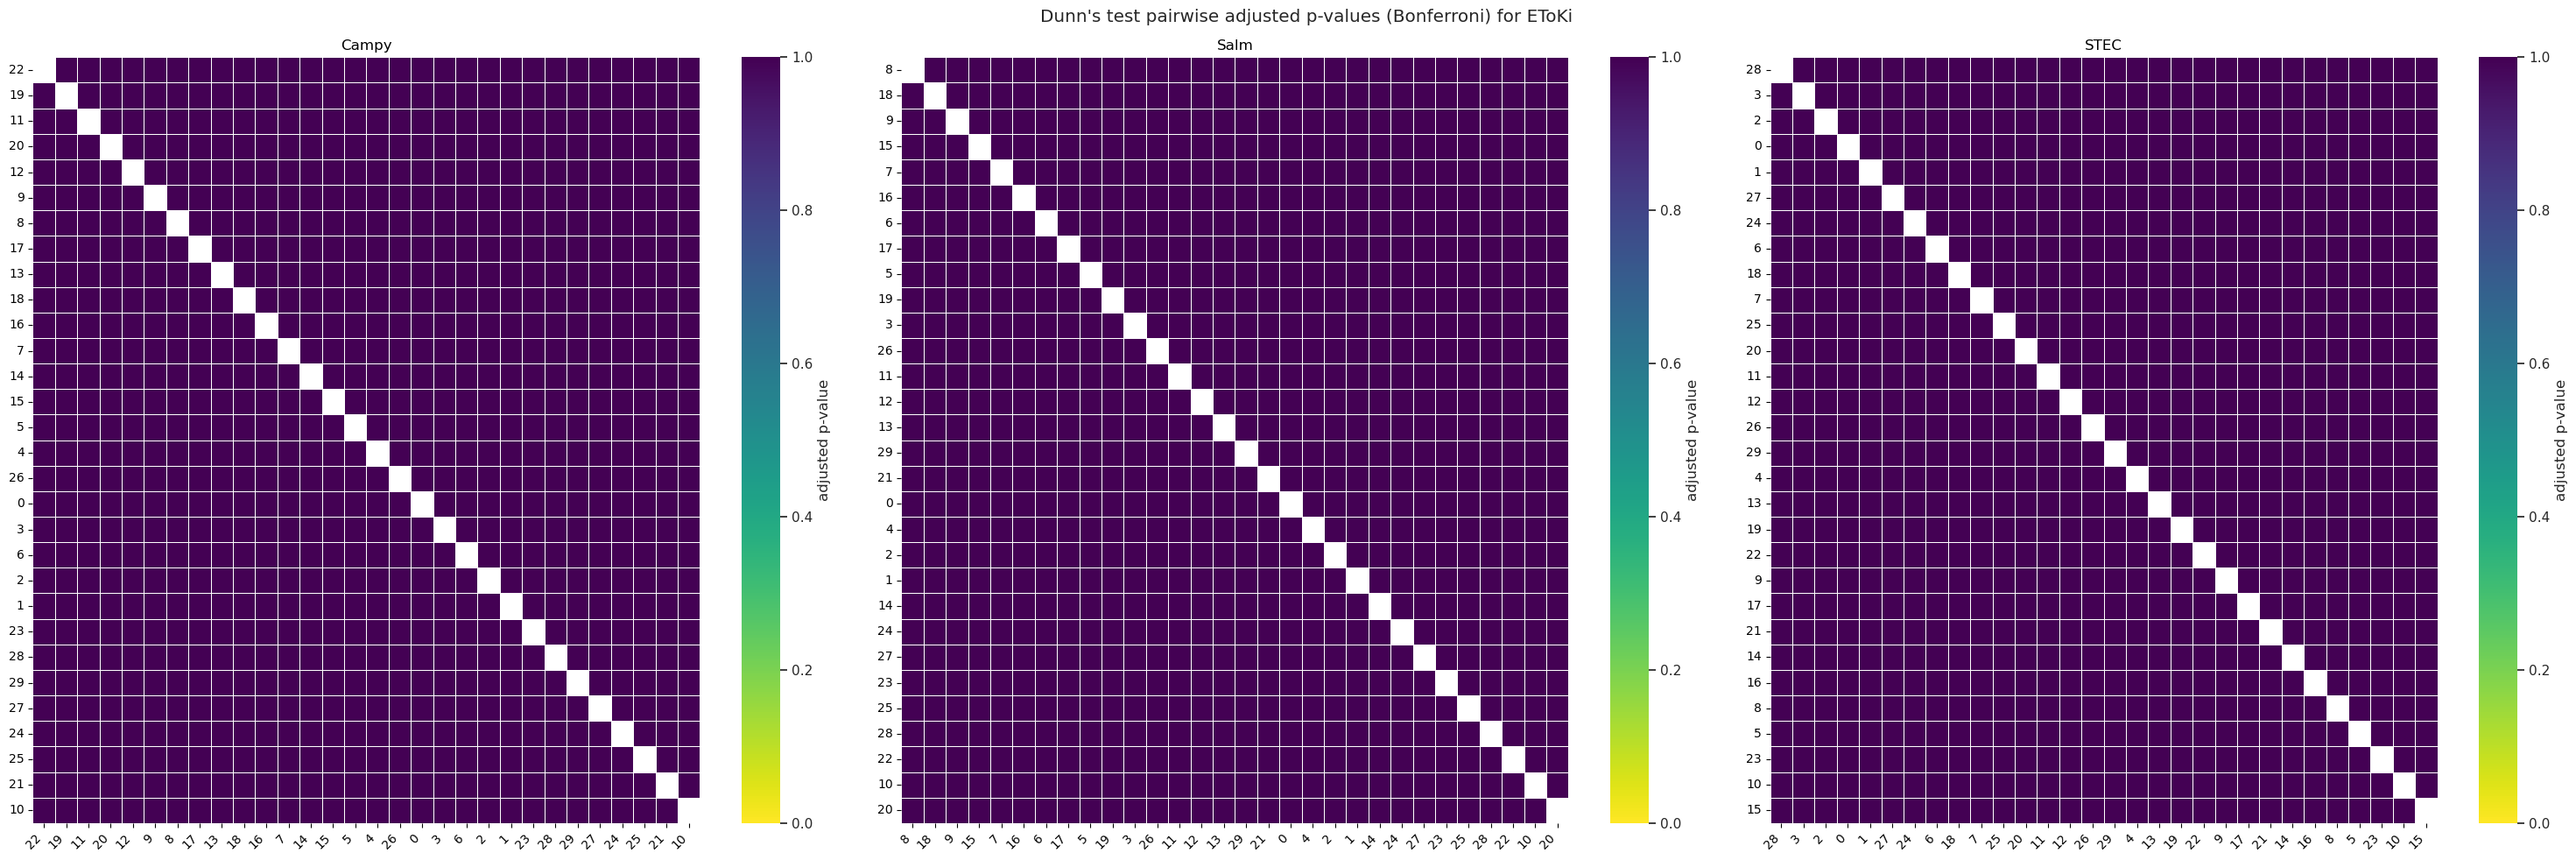

In [12]:
fig_mem, axs_mem = plt.subplots(1,3, figsize=(30,10))
sns.set(style='white')
fig_mem.suptitle("Dunn's test pairwise adjusted p-values (Bonferroni) for EToKi")
#Campy
ax=axs_mem[0]
sns.set(style='white')
sns.heatmap(pvals_c, mask=mask_c, cmap='viridis_r', vmin=0, vmax=1,  # cap color scale at 0.05
                 annot=stars_c, fmt='', cbar_kws={'label': 'adjusted p-value'}, linewidths=.5,
           ax=ax)
ax.set_title("Campy") 
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

#Salm
ax1 = axs_mem[1]
sns.heatmap(pvals_s, mask=mask_s, cmap='viridis_r', vmin=0, vmax=1,
            annot=stars_s, fmt='', cbar_kws={'label': 'adjusted p-value'}, linewidths=.5,
            ax=ax1)
ax1.set_title("Salm")
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax1.get_yticklabels(), rotation=0)

#Escherichia
ax2 = axs_mem[2]
sns.heatmap(pvals_e, mask=mask_e, cmap='viridis_r', vmin=0, vmax=1,
            annot=stars_e, fmt='', cbar_kws={'label': 'adjusted p-value'}, linewidths=.5,
            ax=ax2)
ax2.set_title("STEC")
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax2.get_yticklabels(), rotation=0)

# plt.show()
fig_mem.tight_layout()
plt.savefig("~/MLST/figures_data/kruskal-wallis/etoki_kwheatmaps.png")

## Calculating and Plotting cliff's delta

In [13]:
from itertools import combinations

In [14]:
#Cliff's delta calculation
def cliffs_delta(x,y):
    """
    Compute Cliff's delta for two 1-D arrays x and y.
    Returns delta in [-1, 1] and the counts (n_greater, n_less, n_equal).
    """
    #converting y and x to a Numpy array and excluding NaN
    x = np.asarray(x)[~np.isnan(x)]
    y = np.asarray(y)[~np.isnan(y)]
    n_x = x.size
    n_y = y.size
    if n_x == 0 or n_y == 0:
        return np.nan  # undefined if one group empty
    comp = np.sign(x[:, None] - y[None, :]) #Matrix containing all vs all between x & y
    n_greater = np.sum(comp == 1)
    n_less = np.sum(comp == -1)
    # n_equal = np.sum(comp == 0)
    delta = (n_greater - n_less) / (n_x * n_y)
    return delta

### Campy

In [15]:
#Calculating median differences
cols_c = campy_df.columns.tolist()
campy_medians = campy_df.median()
campy_mediandiff = pd.DataFrame(index=cols_c, columns=cols_c,dtype=float)
for i in cols_c:
    for j in cols_c:
        campy_mediandiff.loc[i, j] = campy_medians[i] - campy_medians[j]
        
#Cliff's matrix
cliff_mat_c = pd.DataFrame(index=cols_c, columns=cols_c, dtype=float)
for i in cols_c:
    xi = campy_df[i].dropna().values
    for j in cols_c:
        yj = campy_df[j].dropna().values
        #calculating delta with cleaned up matrix
        cliff_mat_c.loc[i, j] = cliffs_delta(xi, yj)
        
#Order the cliff's matrix on median values
order_c = campy_medians.sort_values().index.tolist()
campy_mediandiff = campy_mediandiff.loc[order_c, order_c]
cliff_mat_c = cliff_mat_c.loc[order_c, order_c]

### Salm

In [16]:
#Calculating median differences
cols_s = salm_df.columns.tolist()
salm_medians = salm_df.median()
salm_mediandiff = pd.DataFrame(index=cols_s, columns=cols_s,dtype=float)
for i in cols_s:
    for j in cols_s:
        salm_mediandiff.loc[i, j] = salm_medians[i] - salm_medians[j]
        
#Cliff's matrix
cliff_mat_s = pd.DataFrame(index=cols_s, columns=cols_s, dtype=float)
for i in cols_s:
    xi = salm_df[i].dropna().values
    for j in cols_s:
        yj = salm_df[j].dropna().values
        #calculating delta with cleaned up matrix
        cliff_mat_s.loc[i, j] = cliffs_delta(xi, yj)
        
#Order the cliff's matrix on median values
order_s = salm_medians.sort_values().index.tolist()
salm_mediandiff = salm_mediandiff.loc[order_s, order_s]
cliff_mat_s = cliff_mat_s.loc[order_s, order_s]

### Escherichia

In [17]:
#Calculating median differences
cols_e = stec_df.columns.tolist()
stec_medians = stec_df.median()
stec_mediandiff = pd.DataFrame(index=cols_e, columns=cols_e,dtype=float)
for i in cols_e:
    for j in cols_e:
        stec_mediandiff.loc[i, j] = stec_medians[i] - stec_medians[j]
        
#Cliff's matrix
cliff_mat_e = pd.DataFrame(index=cols_e, columns=cols_e, dtype=float)
for i in cols_e:
    xi = stec_df[i].dropna().values
    for j in cols_e:
        yj = stec_df[j].dropna().values
        #calculating delta with cleaned up matrix
        cliff_mat_e.loc[i, j] = cliffs_delta(xi, yj)
        
#Order the cliff's matrix on median values
order_e = stec_medians.sort_values().index.tolist()
stec_mediandiff = stec_mediandiff.loc[order_e, order_e]
cliff_mat_e = cliff_mat_e.loc[order_e, order_e]

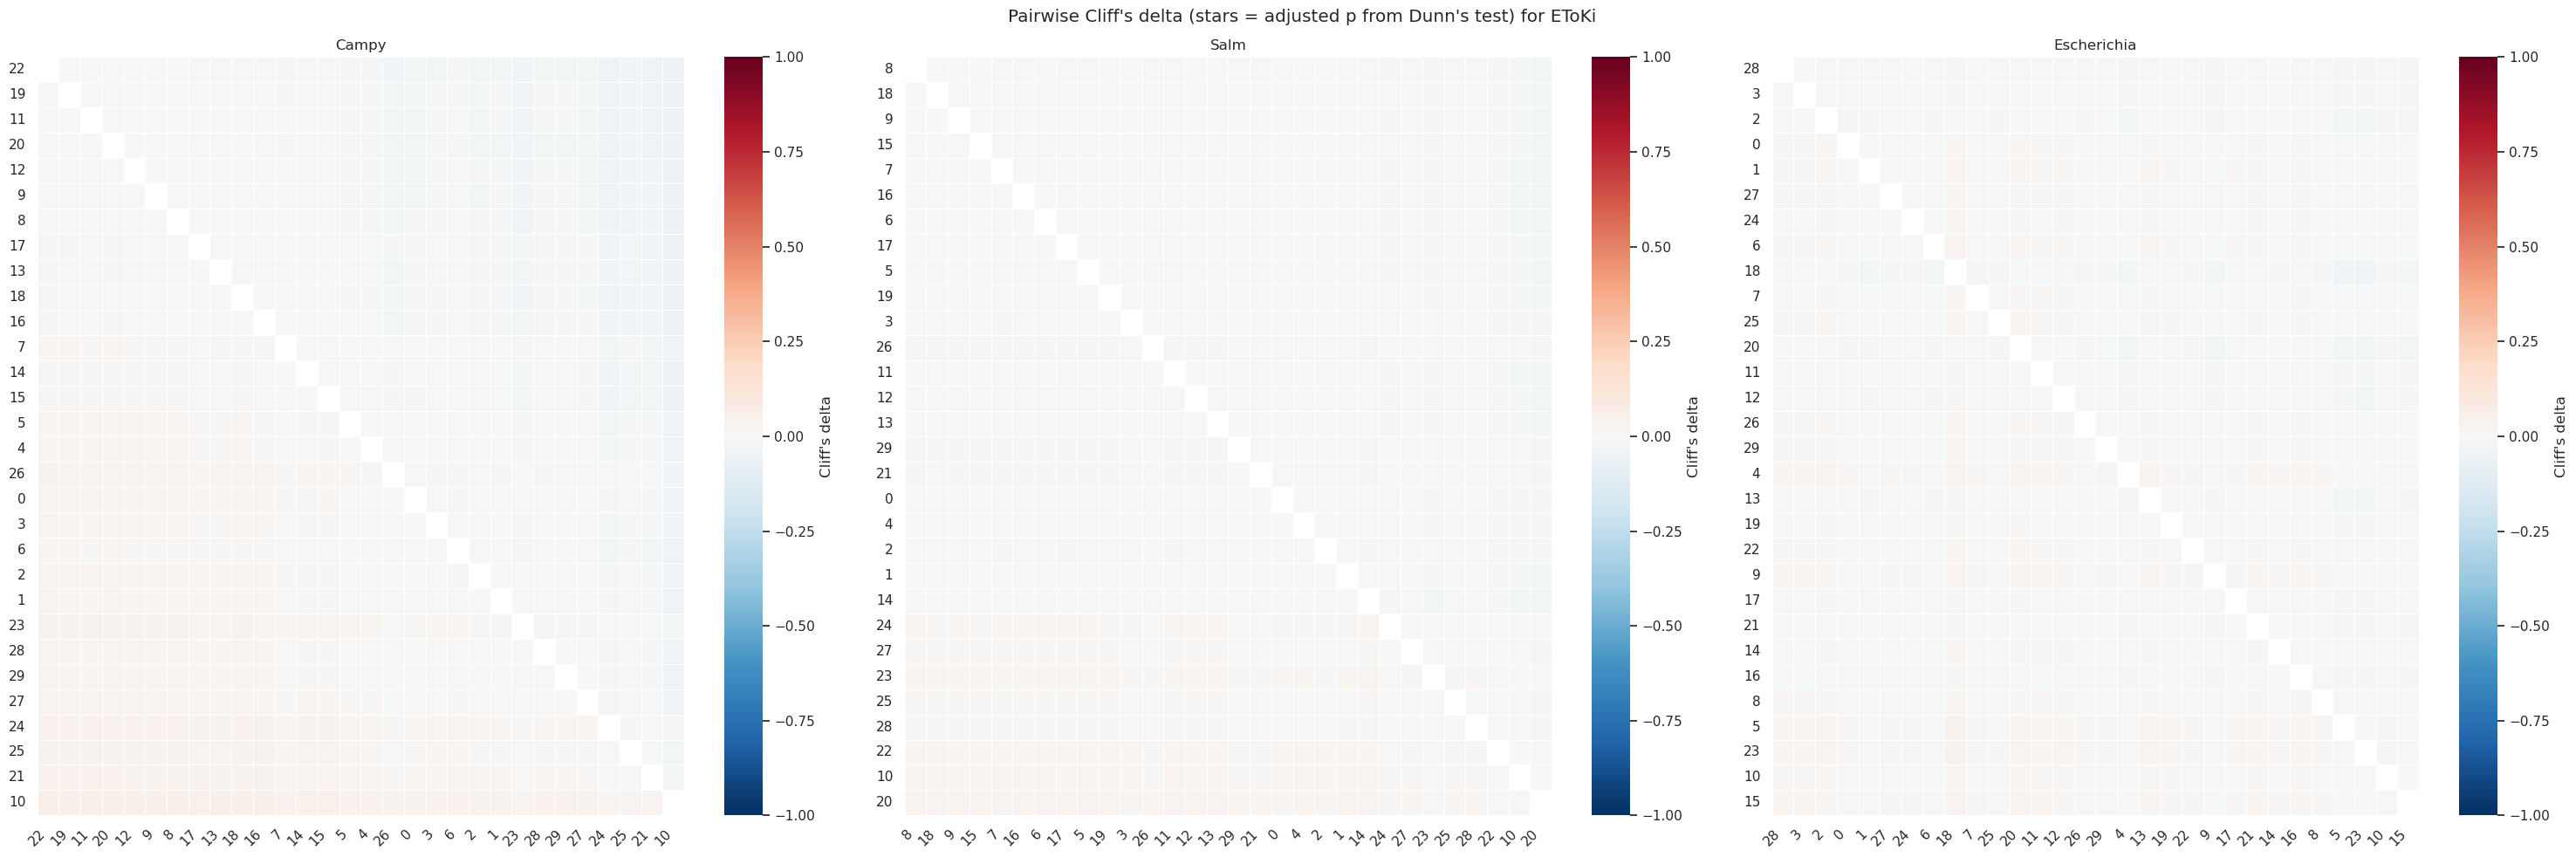

In [18]:
fig,axs = plt.subplots(1,3, figsize=(30,10))
sns.set(style='white')
fig.suptitle("Pairwise Cliff's delta (stars = adjusted p from Dunn's test) for EToKi")

#Campy
ax = axs[0]
sns.heatmap(cliff_mat_c.astype(float), cmap='RdBu_r', center=0,
                 vmin=-1.0, vmax=1.0, mask=mask_c, annot=False,
                 linewidths=0.4, cbar_kws={'label': "Cliff's delta"},ax=ax)

# Overlay stars: iterate cells and put stars where present
# Tune fontsize proportional to number of columns (so not too big)
n_c = len(cliff_mat_c)
fontsize = max(6, min(12, int(200 / n_c)))  # example heuristic

for (i, j), label in np.ndenumerate(stars_c.values):
    if i == j:
        continue
    if label:  # non-empty string of stars
        # choose text color for contrast (white or black)
        cell_val = cliff_mat_c.values[i, j]
        # pick white for dark cells, black for light cells
        # map cell_val to color brightness: near -1/1 -> saturated; near 0 -> light
        text_color = 'white' if abs(cell_val) > 0.45 else 'black'
        ax.text(j + 0.5, i + 0.5, label, ha='center', va='center',
                color=text_color, fontsize=fontsize, fontweight='bold')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)
ax.set_title("Campy")

#Salm
ax1 = axs[1]
sns.heatmap(cliff_mat_s.astype(float), cmap='RdBu_r', center=0,
                 vmin=-1.0, vmax=1.0, mask=mask_s, annot=False,
                 linewidths=0.4, cbar_kws={'label': "Cliff's delta"},ax=ax1)

n_s = len(cliff_mat_s)
fontsize = max(6, min(12, int(200 / n_s)))  # example heuristic

for (i, j), label in np.ndenumerate(stars_s.values):
    if i == j:
        continue
    if label:  # non-empty string of stars
        # choose text color for contrast (white or black)
        cell_val = cliff_mat_s.values[i, j]
        text_color = 'white' if abs(cell_val) > 0.45 else 'black'
        ax1.text(j + 0.5, i + 0.5, label, ha='center', va='center',
                color=text_color, fontsize=fontsize, fontweight='bold')

plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax1.get_yticklabels(), rotation=0)
ax1.set_title("Salm")

#Escherichia
ax2 = axs[2]
sns.heatmap(cliff_mat_e.astype(float), cmap='RdBu_r', center=0,
                 vmin=-1.0, vmax=1.0, mask=mask_e, annot=False,
                 linewidths=0.4, cbar_kws={'label': "Cliff's delta"},ax=ax2)

n_e = len(cliff_mat_e)
fontsize = max(6, min(12, int(200 / n_e)))  # example heuristic

for (i, j), label in np.ndenumerate(stars_e.values):
    if i == j:
        continue
    if label:  # non-empty string of stars
        # choose text color for contrast (white or black)
        cell_val = cliff_mat_e.values[i, j]
        text_color = 'white' if abs(cell_val) > 0.45 else 'black'
        ax2.text(j + 0.5, i + 0.5, label, ha='center', va='center',
                color=text_color, fontsize=fontsize, fontweight='bold')

plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax2.get_yticklabels(), rotation=0)
ax2.set_title("Escherichia")



# plt.show()
fig.tight_layout()
plt.savefig("~/MLST/figures_data/kruskal-wallis/etoki_cdheatmaps.png")